>># ***MASTERCARD CREDIT CARD FRAUD DETECTION SYSTEM*** 
###

### 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.utils import resample

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

### 2. LOAD DATASET

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (284807, 31)


In [4]:
print("\nFirst 5 Rows:\n")
df.head()


First 5 Rows:



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64

In [6]:
print("\nDataset Description:\n")
df.describe()


Dataset Description:



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 3. DATA CLEANING

In [7]:
print("\nMissing Values:\n")
df.isnull().sum()


Missing Values:



Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# Remove duplicates

df.drop_duplicates(inplace=True)

In [9]:
print("\nShape after removing duplicates:", df.shape)


Shape after removing duplicates: (283726, 31)


### 4. FEATURE ENGINEERING

In [10]:
# Log transformation for amount

df["LogAmount"] = np.log1p(df["Amount"])

In [11]:
# Transaction hour extraction

df["TransactionHour"] = df["Time"] // 3600

In [12]:
# Day period categorization

def categorize_hour(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["DayPeriod"] = df["TransactionHour"].apply(categorize_hour)

In [13]:
# Convert categorical to dummy variables

df = pd.get_dummies(df, columns=["DayPeriod"], drop_first=True)

### 5. EXPLORATORY DATA ANALYSIS

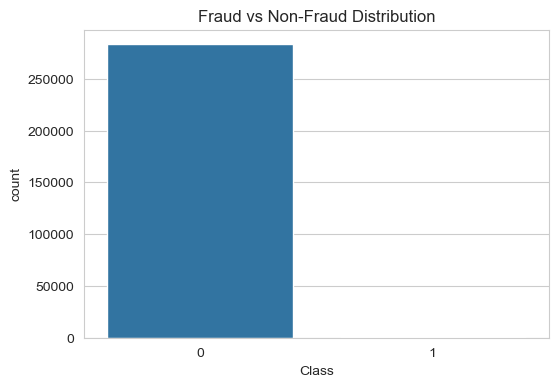

In [14]:
# Fraud vs Non-Fraud distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

In [15]:
fraud_ratio = df["Class"].value_counts(normalize=True)
print("\nFraud Ratio:")
print(fraud_ratio)


Fraud Ratio:
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


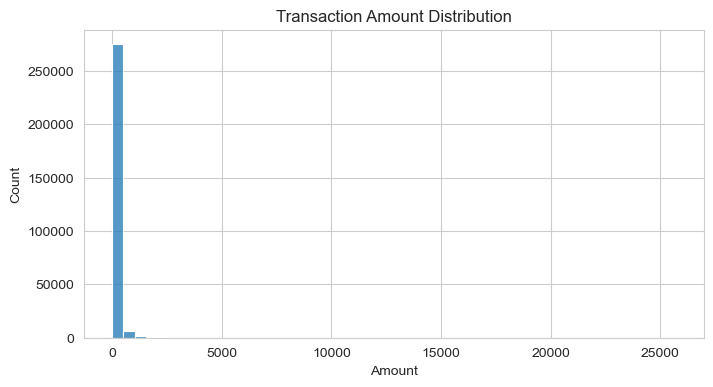

In [16]:
# Transaction Amount Distribution

plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

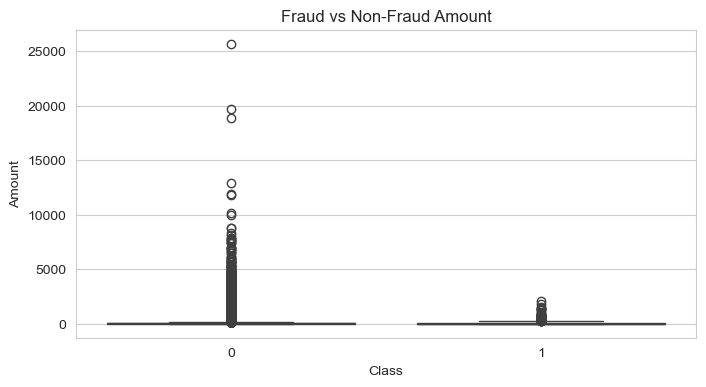

In [17]:
# Fraud Amount Distribution

plt.figure(figsize=(8,4))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Fraud vs Non-Fraud Amount")
plt.show()

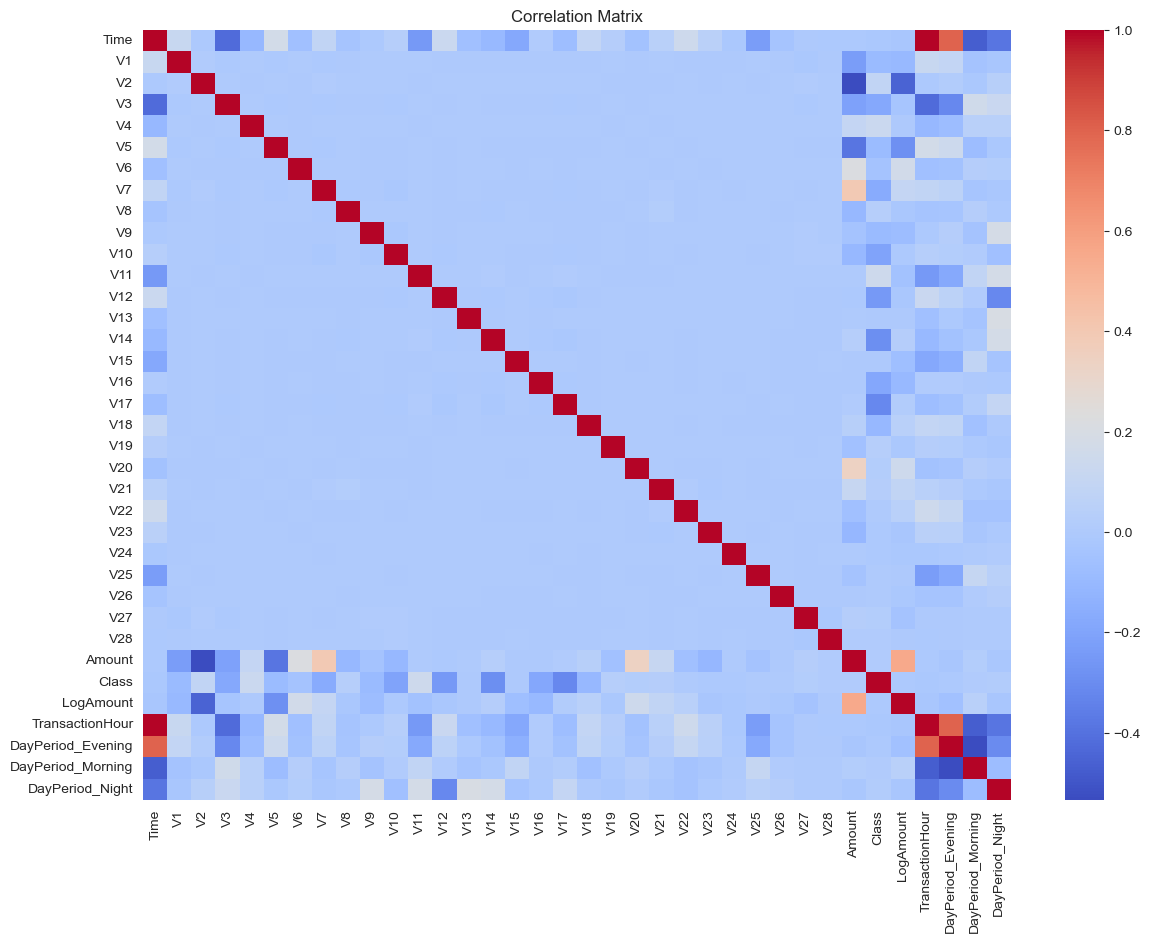

In [18]:
# Correlation Heatmap

plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### 6. HANDLE CLASS IMBALANCE

In [19]:
fraud = df[df.Class == 1]
normal = df[df.Class == 0]

In [20]:
print("\nFraud Transactions:", len(fraud))


Fraud Transactions: 473


In [21]:
print("Normal Transactions:", len(normal))

Normal Transactions: 283253


In [22]:
# Oversampling fraud cases

fraud_oversampled = resample(
    fraud,
    replace=True,
    n_samples=len(normal),
    random_state=42
)

In [23]:
balanced_df = pd.concat([normal, fraud_oversampled])

In [24]:
print("\nBalanced Dataset Shape:", balanced_df.shape)


Balanced Dataset Shape: (566506, 36)


### 7. FEATURE SELECTION

In [25]:
X = balanced_df.drop("Class", axis=1)
y = balanced_df["Class"]

### 8. DATA SPLITTING

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [27]:
print("\nTraining Shape:", X_train.shape)


Training Shape: (424879, 35)


In [28]:
print("Testing Shape:", X_test.shape)

Testing Shape: (141627, 35)


### 9. FEATURE SCALING

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 10. MODEL TRAINING

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=50),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50)
}

results = {}

In [32]:
for name, model in models.items():

    print("\nTraining:", name)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    }


Training: Logistic Regression

Training: Random Forest

Training: Gradient Boosting


### 11. MODEL COMPARISON

In [33]:
results_df = pd.DataFrame(results).T

In [34]:
print("\nModel Performance Comparison:")
print(results_df)


Model Performance Comparison:
                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression  0.946973   0.973784  0.918714  0.945448  0.987913
Random Forest        0.999972   0.999944  1.000000  0.999972  1.000000
Gradient Boosting    0.970924   0.984011  0.957423  0.970535  0.997817


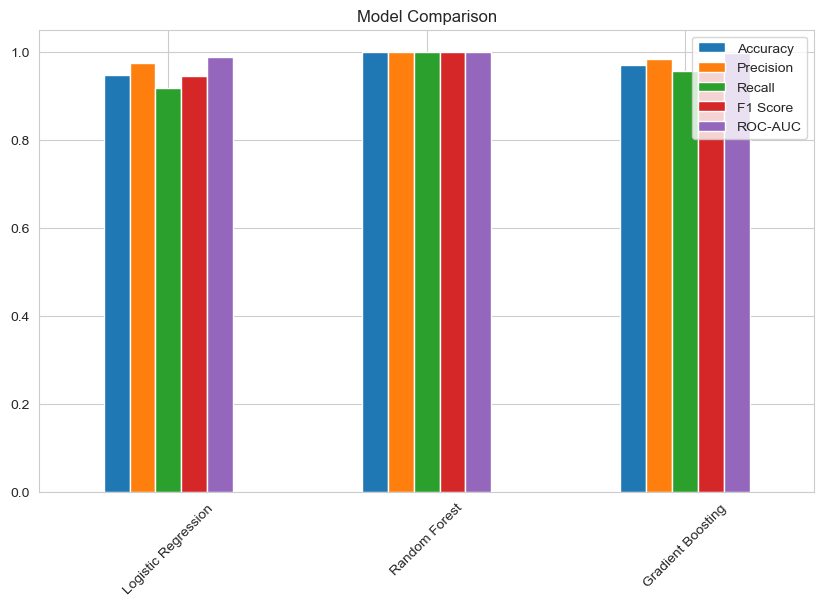

In [35]:
# Visualization

results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

### 12. BEST MODEL SELECTION

In [36]:
best_model_name = results_df["ROC-AUC"].idxmax()
best_model = models[best_model_name]

In [37]:
print("\nBest Model:", best_model_name)


Best Model: Random Forest


### 13. CONFUSION MATRIX

In [38]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

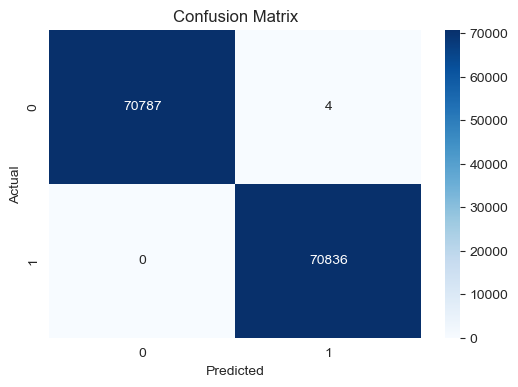

In [39]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70791
           1       1.00      1.00      1.00     70836

    accuracy                           1.00    141627
   macro avg       1.00      1.00      1.00    141627
weighted avg       1.00      1.00      1.00    141627



### 14. ROC CURVE

In [41]:
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

In [42]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

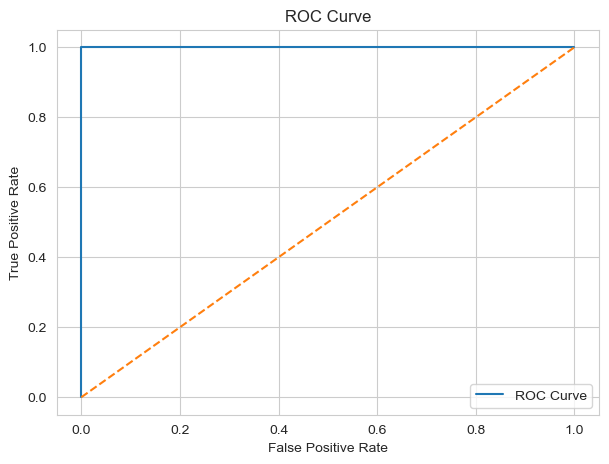

In [43]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### 15. FEATURE IMPORTANCE

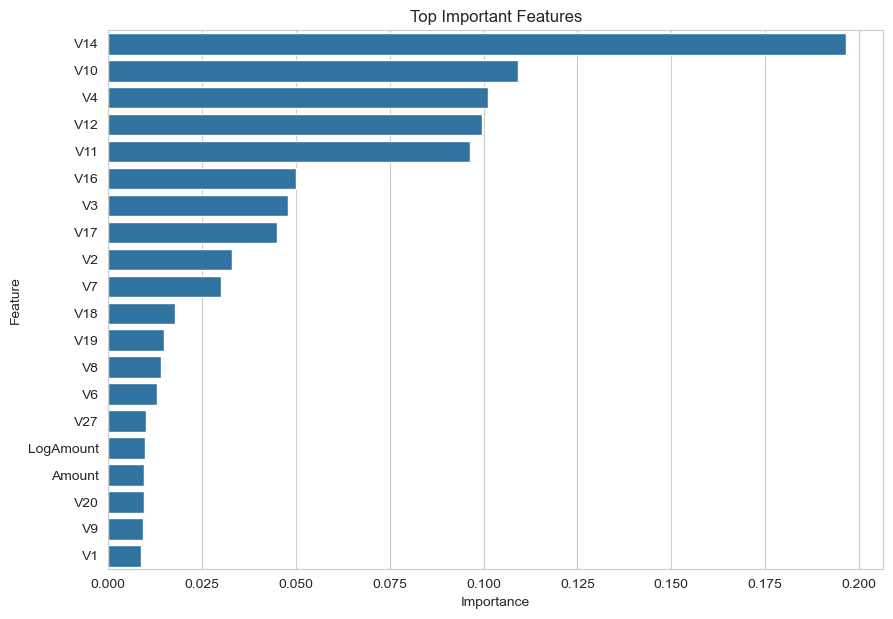

In [44]:
if best_model_name == "Random Forest":

    importance = best_model.feature_importances_

    features = X.columns

    feat_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10,7))
    sns.barplot(x="Importance", y="Feature", data=feat_df.head(20))
    plt.title("Top Important Features")
    plt.show()

### 16. CROSS VALIDATION

In [45]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [46]:
print("\nCross Validation ROC-AUC:", cv_scores.mean())


Cross Validation ROC-AUC: 0.999980582867028


### 17. FRAUD PROBABILITY SCORING

In [47]:
test_sample = X_test.iloc[0].values.reshape(1, -1)
test_sample_scaled = scaler.transform(test_sample)

In [48]:
fraud_prob = best_model.predict_proba(test_sample_scaled)[0][1]

In [49]:
print("\nSample Transaction Fraud Probability:", round(fraud_prob,4))


Sample Transaction Fraud Probability: 1.0


### 18. FRAUD RISK SEGMENTATION

In [50]:
def risk_level(prob):

    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

balanced_df["FraudProbability"] = best_model.predict_proba(
    scaler.transform(X)
)[:,1]

In [51]:
balanced_df["RiskLevel"] = balanced_df["FraudProbability"].apply(risk_level)

In [52]:
print("\nRisk Distribution:")
print(balanced_df["RiskLevel"].value_counts())


Risk Distribution:
RiskLevel
High Risk      283256
Low Risk       283236
Medium Risk        14
Name: count, dtype: int64


### 19. BUSINESS INSIGHTS DATA

In [53]:
fraud_transactions = balanced_df[balanced_df["Class"] == 1]

In [54]:
avg_fraud_amount = fraud_transactions["Amount"].mean()

In [55]:
print("\nAverage Fraud Amount:", avg_fraud_amount)


Average Fraud Amount: 123.24859920283282


### 20. SAVE OUTPUT FILES

In [56]:
balanced_df.to_csv("Fraud_Risk_Predictions.csv", index=False)

In [57]:
results_df.to_csv("Model_Performance_Comparison.csv")

In [58]:
print("\nOutputs Saved Successfully")


Outputs Saved Successfully


# ~~~~~~~~~~~~ END OF FRAUD DETECTION SYSTEM ~~~~~~~~~~~~~